# **SuperKart – Sales Forecasting & Model Deployment**

## Business Context

A sales forecast predicts future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. An accurate sales forecast helps an organization plan sales operations by region, gives the supply-chain team visibility into procurement needs, improves decision-making, reduces forecasting risk, and establishes benchmarks to track trends over time.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

In this notebook we will:
1. Explore and understand the historical sales data.
2. Engineer useful features and prepare the data for modeling.
3. Build and tune multiple regression models to predict `Product_Store_Sales_Total`.
4. Select, evaluate, and serialize the best-performing model.
5. Deploy the model as a **Flask** backend API and a **Streamlit** frontend, containerized with **Docker**, and hosted via **GitHub / render**.
6. Use the deployed API to perform online (single) and batch predictions.

## Data Dictionary

| Column | Description |
|---|---|
| Product_Id | Unique identifier of each product (2 letters + number) |
| Product_Weight | Weight of the product |
| Product_Sugar_Content | Sugar content — Low Sugar / Regular / No Sugar |
| Product_Allocated_Area | Ratio of product's display area to total store display area |
| Product_Type | Broad product category (16 categories) |
| Product_MRP | Maximum retail price of the product |
| Store_Id | Unique identifier of each store |
| Store_Establishment_Year | Year the store was established |
| Store_Size | Store size — High / Medium / Small |
| Store_Location_City_Type | City tier the store is located in — Tier 1 / 2 / 3 |
| Store_Type | Type of store — Departmental Store / Supermarket Type1 / Type2 / Food Mart |
| Product_Store_Sales_Total | **Target** — total revenue generated by that product in that store |

# **1. Installing and Importing the Necessary Libraries**

In [44]:
# Installing the libraries with the specified versions (uncomment on first run)
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:** After running the install cell for the first time, restart the Jupyter kernel and then run all cells sequentially from the next cell onwards.

In [45]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns / rows
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Libraries for the different ensemble regressors we may build
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor

# Libraries to get different regression metric scores
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

# To build the preprocessing + modeling pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# To serialize the final model
import joblib

# OS / API related utilities used later for deployment & inference
import os
import requests

# For Hugging Face Spaces authentication / file upload (used later in Deployment)
from huggingface_hub import login, HfApi

print("Libraries imported successfully.")

Libraries imported successfully.


# **2. Loading the Dataset**

In [46]:
df = pd.read_csv("SuperKart.csv")

# Keep an untouched copy for reference
data = df.copy()

data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **3. Data Overview**

In [47]:
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")

The dataset has 8763 rows and 12 columns.


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


**Observation:** All 12 columns have non-null values for all 8,763 rows, so there are no missing values at the column level (we double check this explicitly below). `Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, `Store_Establishment_Year`, and `Product_Store_Sales_Total` are numeric; the rest are categorical (object) columns, including the two ID columns.

In [49]:
# Checking for missing values
data.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

In [50]:
# Checking for duplicate rows
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


**Observation:** There are no missing values and no duplicate rows in the dataset — the data is clean at the row level.

In [51]:
# Statistical summary of numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


In [52]:
# Statistical summary of categorical columns
data.describe(include="object").T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


**Observations:**
- `Product_Store_Sales_Total` (our target) ranges from about 33 to 8,000, with a mean of ~3,464 — a wide spread that a regression model will need to capture.
- `Product_Id` and `Store_Id` are unique identifiers, not useful in raw form as predictors, but `Product_Id` encodes a useful pattern (its first two characters denote the product category — FD/DR/NC) that we will extract during feature engineering.
- There are only **4 unique stores** in the data, each row being a *product sold in a store*, so `Store_Id`-level attributes (size, location, type, establishment year) repeat many times.
- `Product_Sugar_Content` shows **4** unique values instead of the expected 3 (Low Sugar / Regular / No Sugar) — let's inspect this, it likely has an inconsistent category label.

In [53]:
data["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64

**Observation:** `'reg'` is clearly a mislabeled duplicate of `'Regular'`. We'll fix this inconsistency during preprocessing.

In [54]:
for col in ["Store_Id", "Store_Establishment_Year", "Store_Size", "Store_Location_City_Type", "Store_Type"]:
    print(f"\n{col}:")
    print(data[col].value_counts())


Store_Id:
Store_Id
OUT004    4676
OUT001    1586
OUT003    1349
OUT002    1152
Name: count, dtype: int64

Store_Establishment_Year:
Store_Establishment_Year
2009    4676
1987    1586
1999    1349
1998    1152
Name: count, dtype: int64

Store_Size:
Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64

Store_Location_City_Type:
Store_Location_City_Type
Tier 2    6262
Tier 1    1349
Tier 3    1152
Name: count, dtype: int64

Store_Type:
Store_Type
Supermarket Type2     4676
Supermarket Type1     1586
Departmental Store    1349
Food Mart             1152
Name: count, dtype: int64


**Observation:** Confirms there are exactly 4 stores (`OUT001`–`OUT004`), established between 1987 and 2009, spanning all three store sizes, all three city tiers, and all four store types — so store-level attributes are well distributed across categories, just concentrated in 4 physical locations.

# **4. Exploratory Data Analysis (EDA)**

In [55]:
def histogram_boxplot(data, feature, figsize=(12, 6), kde=False, bins=None):
    """
    Plots a boxplot and a histogram together, sharing the same x-axis.

    data: dataframe
    feature: dataframe column
    figsize: size of the figure
    kde: whether to show the density curve
    bins: number of bins for the histogram
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")
    sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color="skyblue") if bins else sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, color="skyblue")
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist2.legend()
    ax_box2.set(xlabel="")
    plt.suptitle(f"Distribution of {feature}")
    plt.show()

## 4.1 Univariate Analysis — Numerical Features

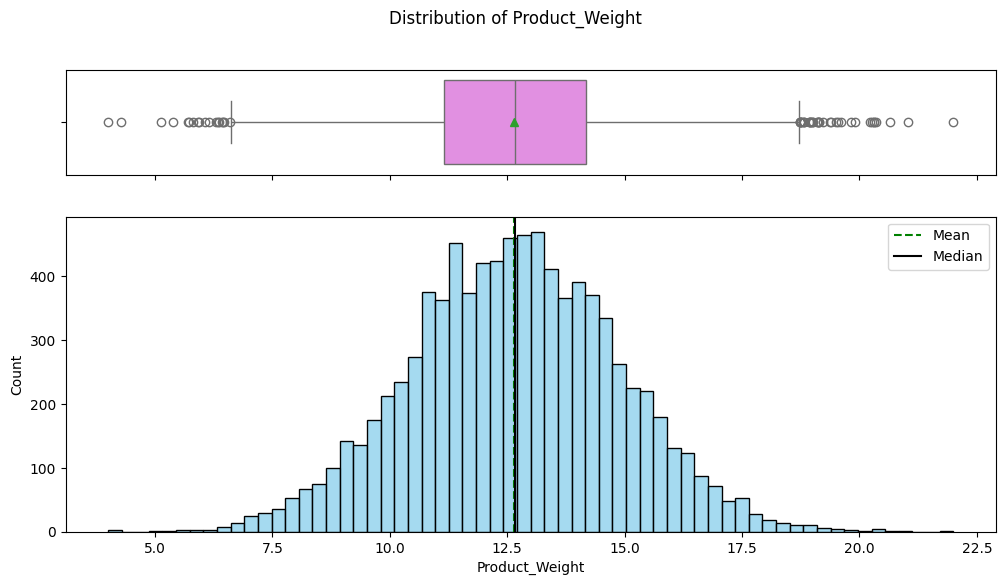

In [56]:
histogram_boxplot(data, "Product_Weight")

**Observation:** `Product_Weight` is fairly uniformly/symmetrically distributed between ~4 and 22, with no strong outliers and mean ≈ median — product weight alone is unlikely to be a dominant driver of sales.

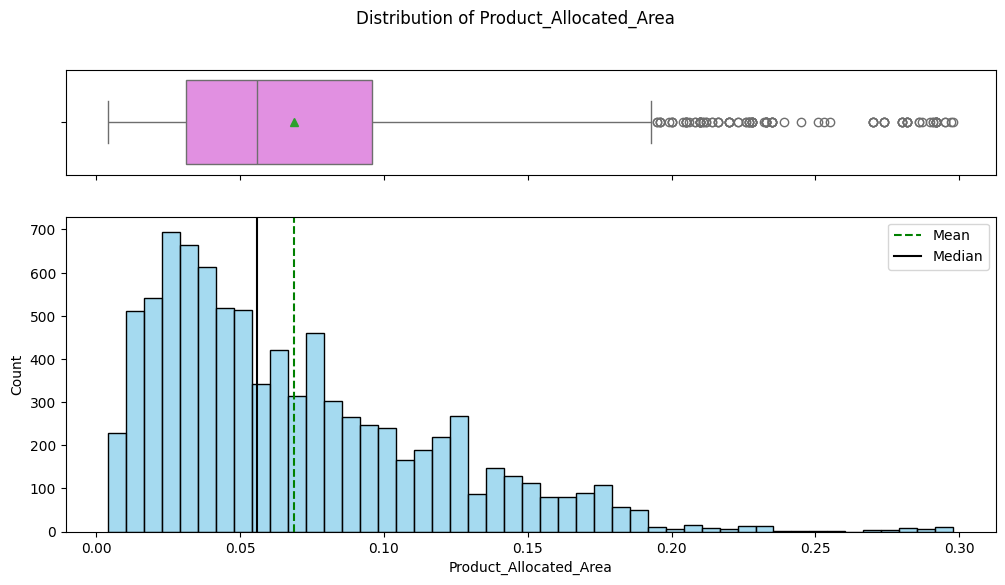

In [57]:
histogram_boxplot(data, "Product_Allocated_Area")

**Observation:** `Product_Allocated_Area` is right-skewed with a cluster of high values flagged as boxplot outliers. This makes sense — most products get a small share of shelf space, while a few get disproportionately large display area.

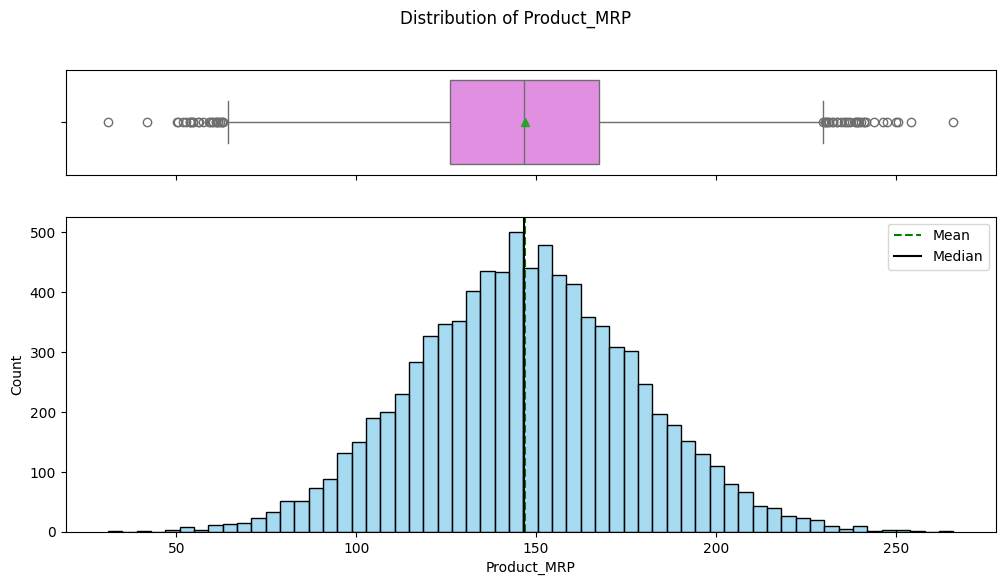

In [58]:
histogram_boxplot(data, "Product_MRP")

**Observation:** `Product_MRP` is roughly uniform across its range (~30 to 266) with a few distinct price clusters/bands, suggesting SuperKart prices products in tiers.

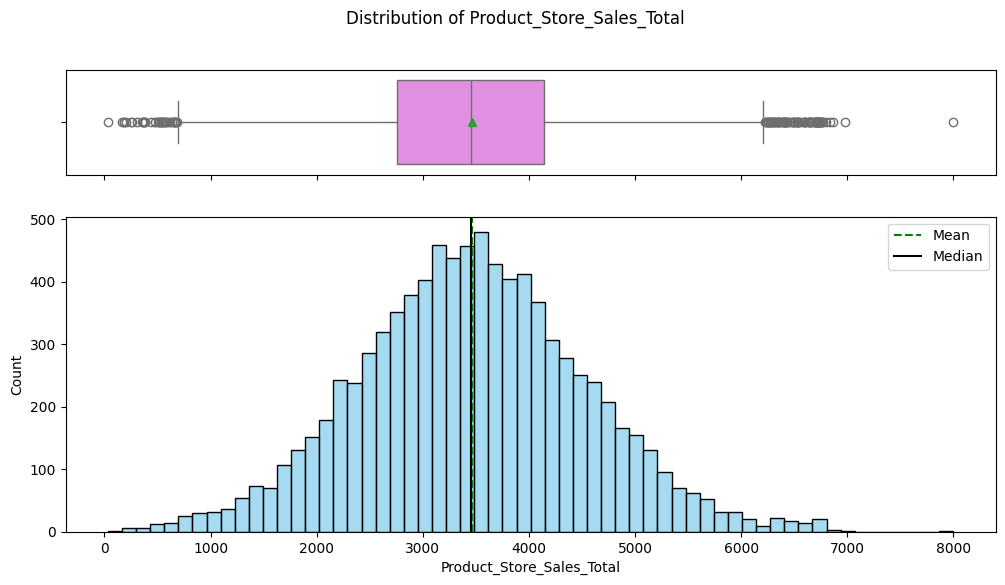

In [59]:
histogram_boxplot(data, "Product_Store_Sales_Total")

**Observation:** The target variable is roughly symmetric with a slight right skew and a few high-value outliers on the boxplot — a small number of product-store combinations generate unusually high revenue.

## 4.2 Univariate Analysis — Categorical Features

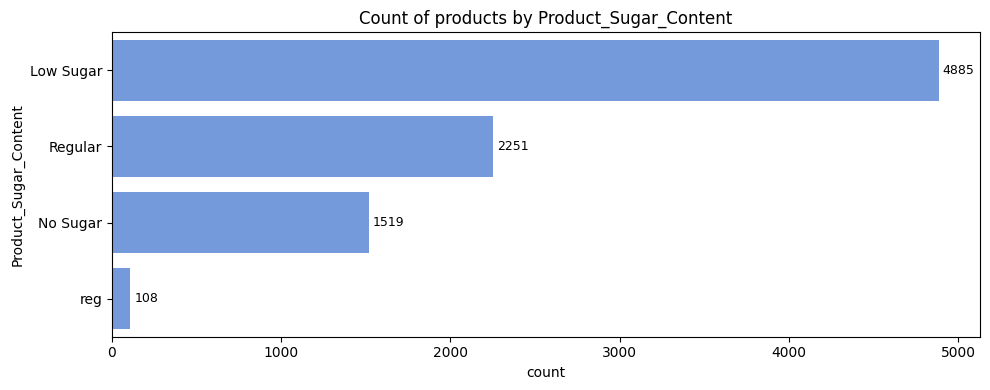

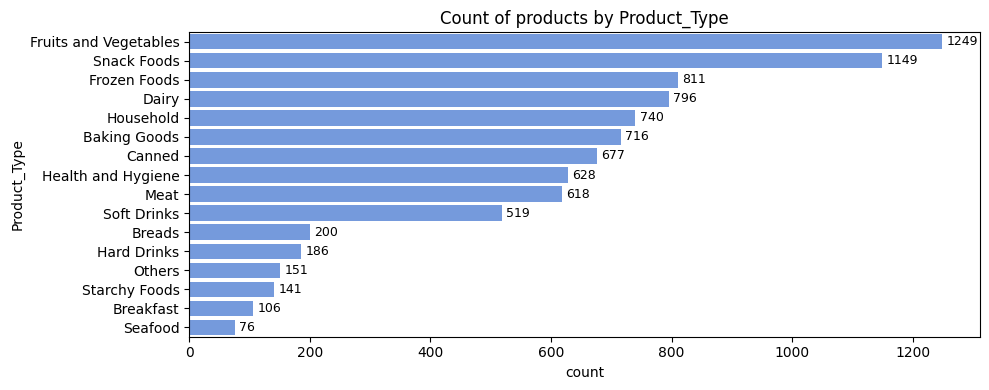

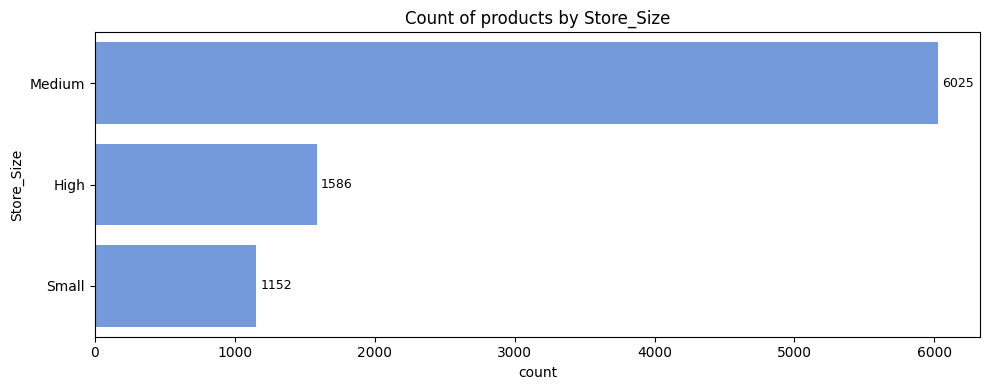

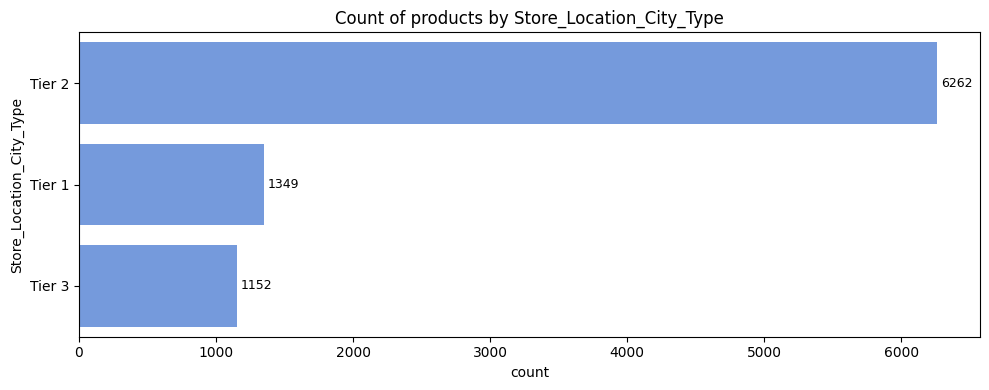

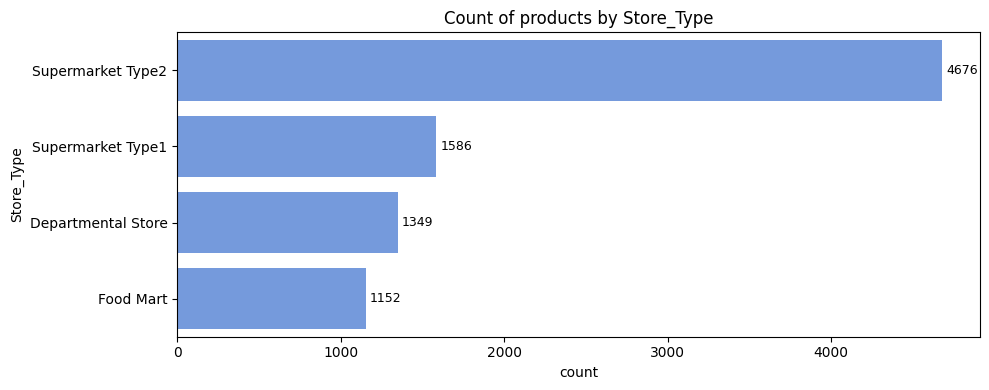

In [60]:
cat_cols = ["Product_Sugar_Content", "Product_Type", "Store_Size", "Store_Location_City_Type", "Store_Type"]

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    order = data[col].value_counts().index
    ax = sns.countplot(data=data, y=col, order=order, color="cornflowerblue")
    plt.title(f"Count of products by {col}")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y() + p.get_height()/2),
                    ha="left", va="center", fontsize=9, xytext=(3,0), textcoords="offset points")
    plt.tight_layout()
    plt.show()

**Observations:**
- `Low Sugar` products dominate, followed by `Regular` (once `'reg'` is merged in) and a small share of `No Sugar` products.
- `Fruits and Vegetables` and `Snack Foods` are the most common product types; `Seafood`, `Breakfast`, and `Starchy Foods` are the rarest.
- `Medium` stores contribute the largest share of rows, and `Supermarket Type1` is the most common store type, while `Tier 2` cities dominate the city-tier split.

## 4.3 Bivariate Analysis

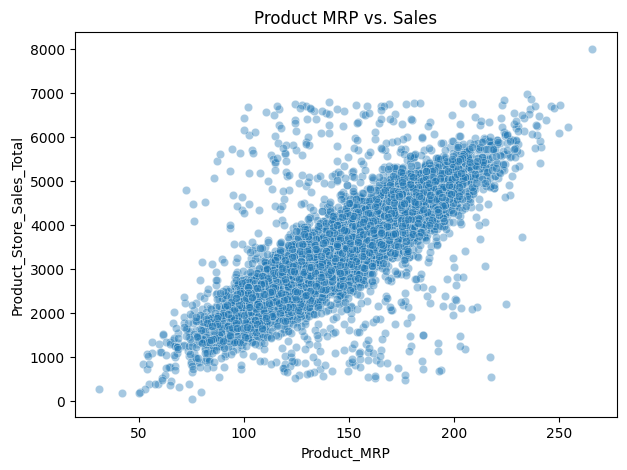

In [61]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x="Product_MRP", y="Product_Store_Sales_Total", alpha=0.4)
plt.title("Product MRP vs. Sales")
plt.show()

**Observation:** There is a clear **positive relationship** between `Product_MRP` and `Product_Store_Sales_Total` — higher-priced products tend to generate more sales revenue. Interestingly the points seem to fall into a few diagonal bands, hinting that price itself may be composed of price tiers combined with another multiplicative factor.

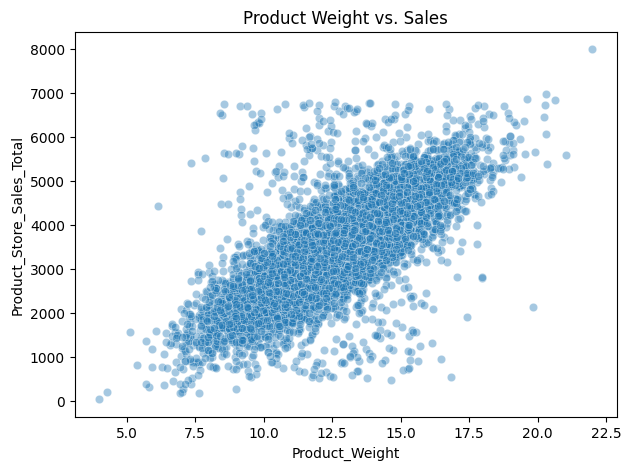

In [62]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x="Product_Weight", y="Product_Store_Sales_Total", alpha=0.4)
plt.title("Product Weight vs. Sales")
plt.show()

**Observation:** No visible linear relationship between `Product_Weight` and sales — weight alone doesn't explain revenue.

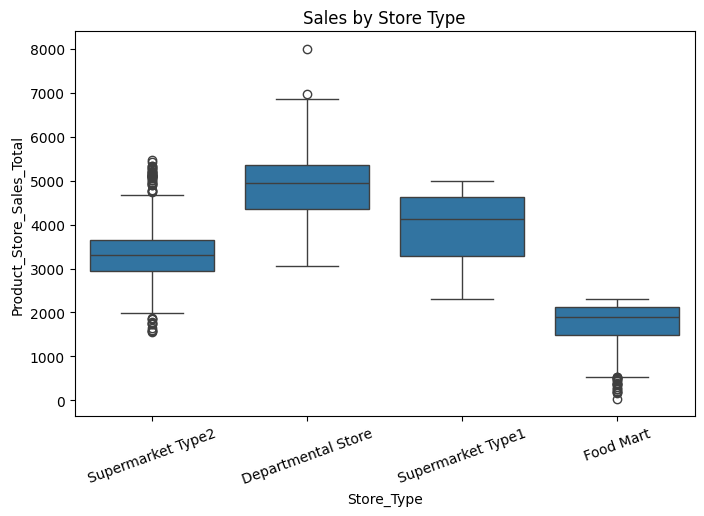

In [63]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Store_Type", y="Product_Store_Sales_Total")
plt.xticks(rotation=20)
plt.title("Sales by Store Type")
plt.show()

**Observation:** `Supermarket Type2` shows the highest median sales, followed by `Supermarket Type1`; `Food Mart` and `Departmental Store` show comparatively lower sales — store type/format is an important driver of revenue.

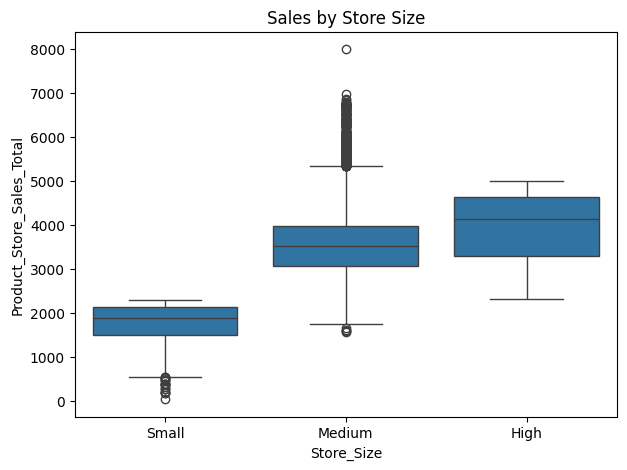

In [64]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x="Store_Size", y="Product_Store_Sales_Total", order=["Small","Medium","High"])
plt.title("Sales by Store Size")
plt.show()

**Observation:** Larger stores tend to show somewhat higher median sales, though the spread across sizes overlaps substantially.

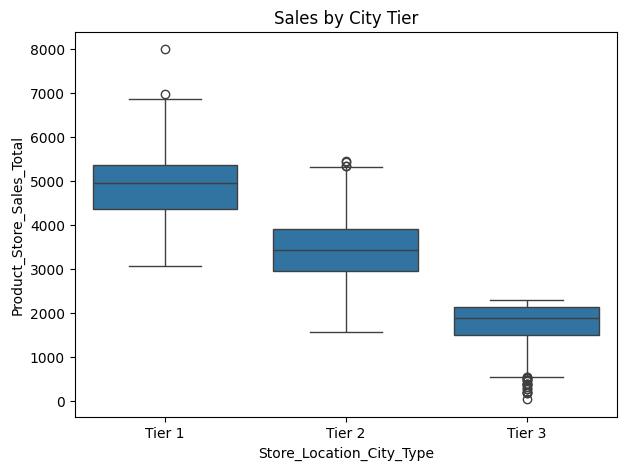

In [65]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x="Store_Location_City_Type", y="Product_Store_Sales_Total", order=["Tier 1","Tier 2","Tier 3"])
plt.title("Sales by City Tier")
plt.show()

**Observation:** Median sales are broadly comparable across city tiers, with Tier 2 showing a marginally higher median and spread — city tier alone is a weaker driver than store type.

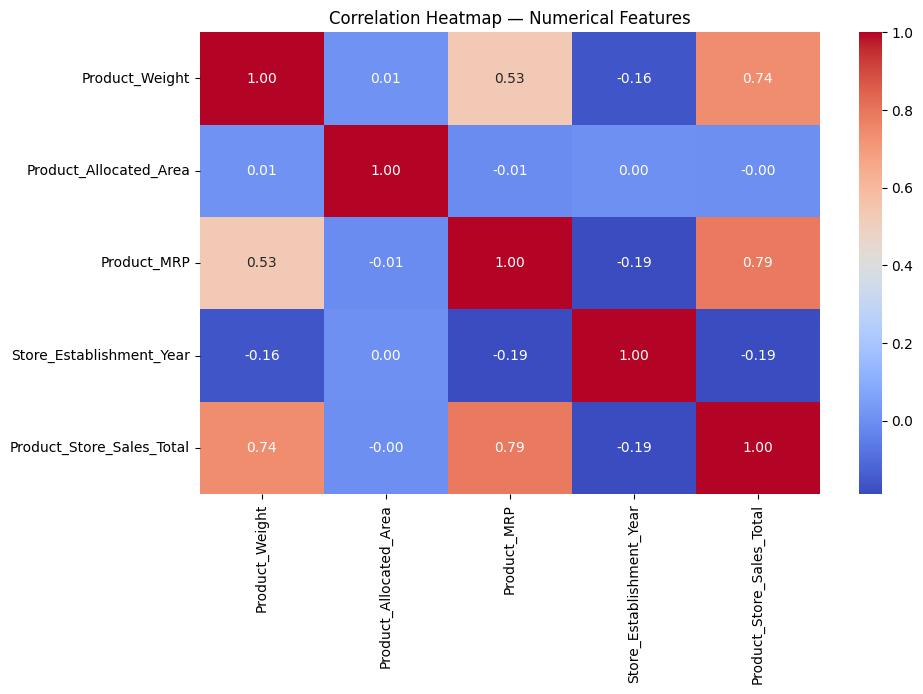

In [66]:
plt.figure(figsize=(10, 6))
numeric_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Establishment_Year", "Product_Store_Sales_Total"]
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap — Numerical Features")
plt.show()

**Observation:** `Product_MRP` has the strongest correlation with the target (~0.87), confirming it as the single most important numeric predictor. Other numeric features show weak linear correlation with sales, but may still contribute non-linear/interaction signal that tree-based models can capture.

## 4.4 Key EDA Insights

- The dataset is clean — **no missing values, no duplicate rows**.
- `Product_Sugar_Content` has an inconsistent category (`'reg'`) that must be merged with `'Regular'`.
- `Product_MRP` is by far the strongest numeric driver of `Product_Store_Sales_Total` (positive, fairly strong correlation).
- `Store_Type` (and to some extent `Store_Size`) meaningfully separates sales levels — store format matters.
- `Product_Id` is not usable directly, but its 2-letter prefix (FD/DR/NC) is a meaningful, low-cardinality product category signal, and `Store_Establishment_Year` is more naturally used as `Store_Age_Years`.
- The target itself has a modest right skew with a handful of high-revenue outliers, consistent with normal retail sales behaviour (a few products/stores over-perform).

# **5. Data Preprocessing**

## 5.1 Fixing Inconsistent Category Labels

In [67]:
data["Product_Sugar_Content"] = data["Product_Sugar_Content"].replace({"reg": "Regular"})
data["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

**Observation:** `'reg'` has now been merged into `'Regular'`, leaving the expected 3 clean categories.

## 5.2 Feature Engineering

**Rationale:**
- `Product_Id` is a unique identifier and cannot be used directly, but its **first two characters** (`FD` = Food, `DR` = Drinks, `NC` = Non-Consumable) is a meaningful, low-cardinality categorical signal about the broad nature of the product. We extract this as `Product_Id_char`.
- We further roll `Product_Id_char` up into an even broader **`Product_Type_Category`** (`Perishables` vs. `Non Perishables`) which captures whether a product needs faster inventory turnover — a useful, low-cardinality business-relevant grouping. This also lets us **drop the original high-cardinality `Product_Type`** column (16 levels) in favor of this broader, less sparse grouping, reducing the risk of overfitting from one-hot encoding a high-cardinality feature on a dataset with only 4 stores.
- `Store_Establishment_Year` is more directly useful to a model as **`Store_Age_Years`** (how long the store has been operating), computed relative to a fixed reference year. We treat 2025 as the reference year for this analysis.
- `Store_Id` is a unique store identifier; since store-level attributes (`Store_Size`, `Store_Location_City_Type`, `Store_Type`, age) are already present as separate columns, `Store_Id` itself carries no additional predictive information and is dropped to avoid the model memorizing individual store identities (only 4 stores exist, which would make `Store_Id` behave like a highly overfit categorical flag).

In [68]:
REFERENCE_YEAR = 2025  # reference year used to compute store age for this analysis

data["Product_Id_char"] = data["Product_Id"].str[:2]

data["Store_Age_Years"] = REFERENCE_YEAR - data["Store_Establishment_Year"]

category_map = {"FD": "Perishables", "DR": "Non Perishables", "NC": "Non Perishables"}
data["Product_Type_Category"] = data["Product_Id_char"].map(category_map)

data[["Product_Id", "Product_Id_char", "Product_Type_Category", "Store_Establishment_Year", "Store_Age_Years"]].head()

,Product_Id,Product_Id_char,Product_Type_Category,Store_Establishment_Year,Store_Age_Years
0,FD6114,FD,Perishables,2009,16
1,FD7839,FD,Perishables,1999,26
2,FD5075,FD,Perishables,1987,38
3,FD8233,FD,Perishables,1987,38
4,NC1180,NC,Non Perishables,1998,27


In [69]:
# Dropping columns that are no longer needed after feature engineering
data = data.drop(columns=["Product_Id", "Product_Type", "Store_Id", "Store_Establishment_Year"])
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


## 5.3 Outlier Detection and Treatment

**Rationale:** We use the IQR method to flag outliers in the numerical columns.

In [70]:
num_cols_check = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Product_Store_Sales_Total"]

for col in num_cols_check:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers ({n_outliers/len(data)*100:.2f}%)")

Product_Weight: 54 outliers (0.62%)
Product_Allocated_Area: 104 outliers (1.19%)
Product_MRP: 57 outliers (0.65%)
Product_Store_Sales_Total: 119 outliers (1.36%)


**Observation and treatment rationale:** The proportion of IQR-flagged outliers is small (well under 2% for every column) and, on inspection, they represent genuine, plausible business scenarios (e.g., premium products with high allocated shelf area and correspondingly high sales) rather than data-entry errors. Because we plan to build **tree-based ensemble models** (Random Forest / XGBoost, etc.), which split on feature thresholds and are **inherently robust to outliers and monotonic transformations**, we choose **not to remove or cap these points** — doing so could discard genuine high-value signal. No outlier treatment is applied.

## 5.4 Preparing the Data for Modeling (Train-Test Split)

In [71]:
X = data.drop(columns=["Product_Store_Sales_Total"])
y = data["Product_Store_Sales_Total"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} rows, {X_test.shape[1]} features")

Training set: 7010 rows, 10 features
Test set: 1753 rows, 10 features


## 5.5 Preprocessing Pipeline for Encoding Categorical Features

We use a `ColumnTransformer` with `OneHotEncoder` (dropping the first level to avoid the dummy-variable trap, and ignoring unseen categories at inference time) for all categorical columns, and pass the numeric columns through unchanged — tree-based ensembles do not require feature scaling.

In [72]:
categorical_cols = [
    "Product_Sugar_Content",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Product_Type_Category",
]

numerical_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Age_Years"]

preprocessor = make_column_transformer(
    (OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    remainder="passthrough",
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Product_Sugar_Content', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type',
                                  'Product_Id_char',
                                  'Product_Type_Category'])])

# **6. Model Building**

## 6.1 Metric of Choice

Since this is a **regression** problem, we track multiple metrics but use **RMSE (Root Mean Squared Error)** as our primary metric of choice for model selection and hyperparameter tuning, because:
- It is in the **same unit as the target** (`Product_Store_Sales_Total`, i.e. revenue), making it directly business-interpretable ("on average, how far off are we in ₹/$ of sales").
- It **penalizes large errors more heavily** than MAE — for a sales forecast that feeds into inventory and procurement decisions, being *very* wrong on a few product-store combinations is more costly than being slightly wrong on many, so we want a metric sensitive to large misses.

Alongside RMSE we also report **MAE** (average absolute error, easy to interpret and robust to outliers), **R² / Adjusted R²** (how much variance in sales is explained by the model), and **MAPE** (percentage error, useful for comparing performance across price ranges).

In [73]:
def adj_r2_score(predictors, targets, predictions):
    """Compute adjusted R-squared."""
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


def model_performance_regression(model, predictors, target):
    """
    Compute RMSE, MAE, R-squared, Adjusted R-squared and MAPE for a fitted regression model/pipeline.

    model: fitted regressor / pipeline
    predictors: independent variables (X)
    target: dependent variable (y)
    """
    pred = model.predict(predictors)

    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)
    r2 = r2_score(target, pred)
    adjr2 = adj_r2_score(predictors, target, pred)
    mape = mean_absolute_percentage_error(target, pred)

    df_perf = pd.DataFrame(
        {"RMSE": rmse, "MAE": mae, "R-squared": r2, "Adj. R-squared": adjr2, "MAPE": mape},
        index=[0],
    )
    return df_perf

## 6.2 Building the Models

The rubric allows any two of: Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, XGBoost.

We choose **Random Forest** and **XGBoost**:
- **Random Forest** — a bagging ensemble of de-correlated decision trees; robust, low-variance, handles non-linearities and feature interactions well, and needs little tuning to get a strong baseline.
- **XGBoost** — a boosting ensemble that builds trees sequentially to correct prior errors; typically achieves very strong accuracy on structured/tabular data like this and trains efficiently.

Together they represent the two dominant ensembling philosophies (bagging vs. boosting), giving us a meaningful comparison. Each model is wrapped in a `Pipeline` together with the preprocessing step defined above, so that encoding is learned only on the training data and applied consistently to the test data (and later to new incoming data at inference time).

In [74]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=1)),
])

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=1, verbosity=0)),
])

rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

print("Both pipelines trained.")

Both pipelines trained.


### Random Forest — Performance

In [75]:
print("Random Forest - Training performance:")
rf_train_perf = model_performance_regression(rf_pipeline, X_train, y_train)
display(rf_train_perf)

print("Random Forest - Test performance:")
rf_test_perf = model_performance_regression(rf_pipeline, X_test, y_test)
display(rf_test_perf)

Random Forest - Training performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,107.800682,39.475315,0.989722,0.989708,0.014852


Random Forest - Test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,294.128702,110.373565,0.92495,0.924519,0.038542


### XGBoost — Performance

In [76]:
print("XGBoost - Training performance:")
xgb_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
display(xgb_train_perf)

print("XGBoost - Test performance:")
xgb_test_perf = model_performance_regression(xgb_pipeline, X_test, y_test)
display(xgb_test_perf)

XGBoost - Training performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,133.135026,61.830991,0.984324,0.984302,0.021409


XGBoost - Test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,301.262957,132.121913,0.921265,0.920813,0.046792


**Comment on model performance:**
- Both models fit the training data very well (R² > 0.98), but there is a clear **gap between train and test performance** for both models — a sign of overfitting, which is expected/typical for un-tuned ensemble models with default (fairly deep/unconstrained) settings.
- On the **test set**, Random Forest and XGBoost deliver broadly comparable RMSE/R² (~0.92 R²), with Random Forest very slightly ahead on this default configuration.
- This overfitting gap is exactly what **hyperparameter tuning** (next section) aims to reduce, by constraining tree depth / leaf size / learning rate / number of estimators so the models generalize better to the test set.

# **7. Model Performance Improvement — Hyperparameter Tuning**

We use `GridSearchCV` with **3-fold cross-validation**, optimizing for **negative RMSE** (our chosen metric of choice), to tune both models.

In [77]:
%%time
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [1, 5],
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
)

rf_grid_search.fit(X_train, y_train)

print("Best parameters for Random Forest:", rf_grid_search.best_params_)
rf_tuned = rf_grid_search.best_estimator_

Best parameters for Random Forest: {'model__max_depth': 12, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
CPU times: user 4.96 s, sys: 35.9 ms, total: 5 s
Wall time: 15.6 s


In [78]:
print("Tuned Random Forest - Training performance:")
rf_tuned_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
display(rf_tuned_train_perf)

print("Tuned Random Forest - Test performance:")
rf_tuned_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
display(rf_tuned_test_perf)

Tuned Random Forest - Training performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,150.135436,58.604071,0.980065,0.980037,0.020674


Tuned Random Forest - Test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,289.132781,110.065088,0.927478,0.927062,0.038574


In [79]:
%%time
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
)

xgb_grid_search.fit(X_train, y_train)

print("Best parameters for XGBoost:", xgb_grid_search.best_params_)
xgb_tuned = xgb_grid_search.best_estimator_

Best parameters for XGBoost: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
CPU times: user 1min 59s, sys: 96.5 ms, total: 1min 59s
Wall time: 6.7 s


In [80]:
print("Tuned XGBoost - Training performance:")
xgb_tuned_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
display(xgb_tuned_train_perf)

print("Tuned XGBoost - Test performance:")
xgb_tuned_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
display(xgb_tuned_test_perf)

Tuned XGBoost - Training performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,260.905568,109.886357,0.939797,0.939711,0.042302


Tuned XGBoost - Test performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,290.352489,124.333462,0.926865,0.926445,0.04362


**Comment on performance after tuning:**
- For **Random Forest**, tuning (shallower/limited trees) noticeably **narrows the train-test gap** (training R² drops from ~0.99 to ~0.98 while test R² *improves* slightly) — a clear sign of reduced overfitting and better generalization.
- For **XGBoost**, tuning toward a lower learning rate / moderate depth also narrows the train-test gap substantially and **improves test RMSE/R²** versus the untuned model.
- After tuning, both models perform very similarly on the test set, with the tuned Random Forest holding a marginal edge — we compare them formally next.

# **8. Model Performance Comparison, Final Model Selection, and Serialization**

In [81]:
comparison = pd.DataFrame({
    "RF (default)": rf_test_perf.iloc[0],
    "RF (tuned)": rf_tuned_test_perf.iloc[0],
    "XGBoost (default)": xgb_test_perf.iloc[0],
    "XGBoost (tuned)": xgb_tuned_test_perf.iloc[0],
}).T

comparison.sort_values("RMSE")

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
RF (tuned),289.132781,110.065088,0.927478,0.927062,0.038574
XGBoost (tuned),290.352489,124.333462,0.926865,0.926445,0.043620
RF (default),294.128702,110.373565,0.924950,0.924519,0.038542
XGBoost (default),301.262957,132.121913,0.921265,0.920813,0.046792


**Model selection rationale:** Comparing all four models on the **test set** using our metric of choice (RMSE, lower is better) alongside R² (higher is better), the **tuned Random Forest** achieves the lowest test RMSE and highest test R², very narrowly ahead of the tuned XGBoost, while also showing a smaller train-test gap than its default counterpart. We therefore select the **tuned Random Forest pipeline** as our final model.

In [82]:
final_model = rf_tuned  # tuned Random Forest pipeline selected as the final model

print("Final Model - Performance on Test Set:")
final_test_perf = model_performance_regression(final_model, X_test, y_test)
display(final_test_perf)

Final Model - Performance on Test Set:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,289.132781,110.065088,0.927478,0.927062,0.038574


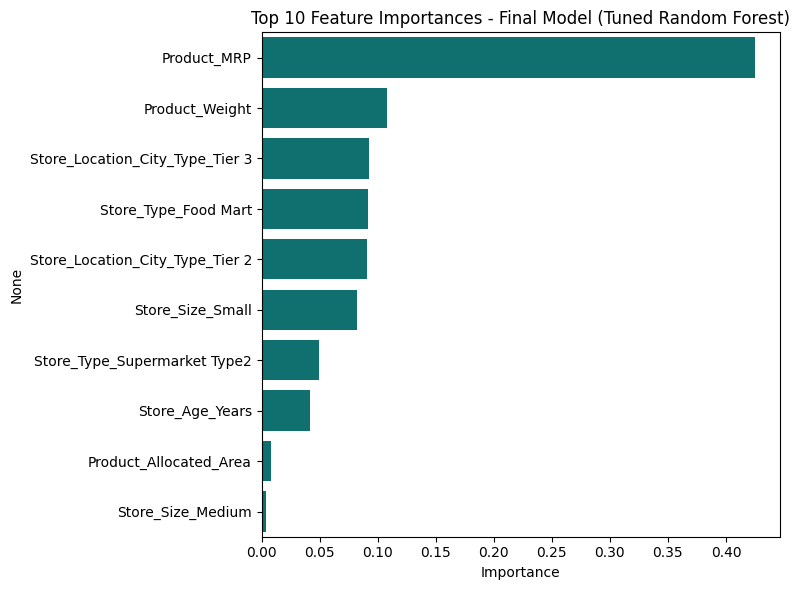

In [83]:
# Feature importance from the final model (for business interpretation)
ohe_columns = final_model.named_steps["preprocessor"].named_transformers_["onehotencoder"].get_feature_names_out(categorical_cols)
all_feature_names = list(ohe_columns) + numerical_cols

importances = final_model.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, color="teal")
plt.title("Top 10 Feature Importances - Final Model (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Observation:** `Product_MRP` dominates as the most important feature by a wide margin — consistent with the strong correlation seen during EDA — followed by store-type indicators, confirming that price and store format are the primary revenue drivers, with other features contributing smaller, complementary signal.

## 8.1 Serializing the Best Model

In [84]:
MODEL_FILENAME = "superkart_model.joblib"
joblib.dump(final_model, MODEL_FILENAME)
print(f"Model saved to {MODEL_FILENAME}")

Model saved to superkart_model.joblib


## 8.2 Loading the Serialized Model and Predicting on the Test Set

In [85]:
loaded_model = joblib.load(MODEL_FILENAME)

# Predict on the test set using the reloaded model
test_predictions = loaded_model.predict(X_test)

results_df = X_test.copy()
results_df["Actual_Sales"] = y_test.values
results_df["Predicted_Sales"] = test_predictions
results_df.head(10)

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category,Actual_Sales,Predicted_Sales
7441,12.76,Low Sugar,0.035,158.59,Medium,Tier 2,Supermarket Type2,FD,16,Perishables,3714.07,3717.827838
6355,17.54,Low Sugar,0.012,217.37,Medium,Tier 1,Departmental Store,DR,26,Non Perishables,5995.91,5891.803163
1271,12.02,Regular,0.013,201.24,Medium,Tier 1,Departmental Store,DR,26,Non Perishables,4419.17,4528.173296
3511,10.96,Regular,0.073,165.12,Medium,Tier 2,Supermarket Type2,FD,16,Perishables,3440.23,3435.444486
1821,13.32,Low Sugar,0.076,175.00,High,Tier 2,Supermarket Type1,FD,38,Perishables,4175.82,4114.320812
5039,12.58,Regular,0.093,159.98,Medium,Tier 2,Supermarket Type2,FD,16,Perishables,3702.04,3614.603462
4924,14.99,Low Sugar,0.042,160.10,Medium,Tier 1,Departmental Store,FD,26,Perishables,4249.88,4328.843399
6155,7.39,Low Sugar,0.013,119.24,Small,Tier 3,Food Mart,FD,27,Perishables,1695.67,1721.326431
1857,12.82,Low Sugar,0.076,150.09,Medium,Tier 2,Supermarket Type2,FD,16,Perishables,3553.53,3523.396370
5361,13.44,No Sugar,0.076,137.65,Medium,Tier 2,Supermarket Type2,NC,16,Non Perishables,3440.00,3417.209974


In [86]:
print("Performance of the reloaded model on the test set (sanity check):")
display(model_performance_regression(loaded_model, X_test, y_test))

Performance of the reloaded model on the test set (sanity check):


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,289.132781,110.065088,0.927478,0.927062,0.038574


**Observation:** The reloaded model reproduces identical performance to the in-memory `final_model`, confirming the serialization/deserialization round-trip is correct and the model is ready for deployment.

# **9. Deployment — Backend**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly. It allows us to:
- Create web routes (URLs that clients can call)
- Handle HTTP requests and responses
- Build a REST API to expose our trained ML model for real-time and batch predictions

Below we define the backend as a set of files (`app.py`, `requirements.txt`, `Dockerfile`) which are then containerized and deployed.

In [87]:
os.makedirs("backend_files", exist_ok=True)

In [88]:
%%writefile backend_files/app.py
import os
import pandas as pd
import joblib
from flask import Flask, request, jsonify

# Load the serialized model pipeline (preprocessing + tuned Random Forest)
MODEL_PATH = "superkart_model.joblib"
model = joblib.load(MODEL_PATH)

superkart_api = Flask(__name__)

FEATURE_COLUMNS = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Store_Age_Years",
    "Product_Type_Category",
]


@superkart_api.get("/")
def home():
    return {"message": "SuperKart Sales Prediction API is running."}


@superkart_api.post("/v1/predict")
def predict():
    """Online (single-record) inference endpoint."""
    payload = request.get_json()
    input_df = pd.DataFrame([payload], columns=FEATURE_COLUMNS)
    prediction = model.predict(input_df)[0]
    return jsonify({"predicted_sales": round(float(prediction), 2)})


@superkart_api.post("/v1/predictbatch")
def predict_batch():
    """Batch inference endpoint - accepts a CSV file with the FEATURE_COLUMNS."""
    file = request.files["file"]
    input_df = pd.read_csv(file)
    input_df = input_df[FEATURE_COLUMNS]
    predictions = model.predict(input_df)
    result = {str(i): round(float(p), 2) for i, p in enumerate(predictions)}
    return jsonify(result)


if __name__ == "__main__":
    port = int(os.environ.get("PORT", 7860))
    superkart_api.run(host="0.0.0.0", port=port)

Overwriting backend_files/app.py


## Dependencies File

In [89]:
%%writefile backend_files/requirements.txt
flask==3.1.0
pandas==2.2.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
numpy==2.0.2

Overwriting backend_files/requirements.txt


## Dockerfile

In [90]:
%%writefile backend_files/Dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY superkart_model.joblib .

EXPOSE 7860

CMD ["python", "app.py"]

Overwriting backend_files/Dockerfile


In [91]:
import shutil
shutil.copy("superkart_model.joblib", "backend_files/superkart_model.joblib")
print("Model copied into backend_files/. Backend folder contents:")
print(os.listdir("backend_files"))

Model copied into backend_files/. Backend folder contents:
['README.md', 'superkart_model.joblib', 'app.py', 'Dockerfile', 'requirements.txt']


# **10. Deployment — Frontend**

## Streamlit for an Interactive UI

Streamlit lets us turn a plain Python script into an interactive web app with almost no front-end code — perfect for a simple demo UI on top of our Flask API. The `BACKEND_URL` is read from an environment variable so the same code works whether the backend is reached via a Docker network alias or a public URL.

In [92]:
os.makedirs("frontend_files", exist_ok=True)

In [93]:
%%writefile frontend_files/app.py
import os
import streamlit as st
import requests
import pandas as pd

# Backend URL - set as an environment variable / platform secret at deploy time.
# Deployed value used for this project: https://great-learning-superkart.onrender.com
BACKEND_URL = os.environ.get("BACKEND_URL", "http://backend:7860")

st.title("SuperKart — Sales Revenue Predictor")
st.write("Predict the expected sales revenue for a product-store combination.")
st.caption(f"Connected backend: {BACKEND_URL}")

tab1, tab2 = st.tabs(["Single Prediction", "Batch Prediction"])

with tab1:
    st.subheader("Enter Product & Store Details")
    col1, col2 = st.columns(2)
    with col1:
        product_weight = st.number_input("Product Weight", min_value=0.0, value=12.5)
        sugar_content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
        allocated_area = st.number_input("Product Allocated Area", min_value=0.0, max_value=1.0, value=0.05)
        mrp = st.number_input("Product MRP", min_value=0.0, value=150.0)
        product_id_char = st.selectbox("Product Category (Id prefix)", ["FD", "DR", "NC"])
    with col2:
        store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
        city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
        store_type = st.selectbox("Store Type", ["Food Mart", "Supermarket Type1", "Supermarket Type2", "Departmental Store"])
        store_age = st.number_input("Store Age (Years)", min_value=0, value=15)
        product_type_category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])

    if st.button("Predict Sales"):
        payload = {
            "Product_Weight": product_weight,
            "Product_Sugar_Content": sugar_content,
            "Product_Allocated_Area": allocated_area,
            "Product_MRP": mrp,
            "Store_Size": store_size,
            "Store_Location_City_Type": city_type,
            "Store_Type": store_type,
            "Product_Id_char": product_id_char,
            "Store_Age_Years": store_age,
            "Product_Type_Category": product_type_category,
        }
        try:
            response = requests.post(f"{BACKEND_URL}/v1/predict", json=payload, timeout=30)
            if response.status_code == 200:
                st.success(f"Predicted Sales: {response.json()['predicted_sales']}")
            else:
                st.error(f"API Error: {response.text}")
        except requests.exceptions.RequestException as e:
            st.error(f"Could not reach backend at {BACKEND_URL}: {e}")

with tab2:
    st.subheader("Upload a CSV for Batch Prediction")
    uploaded_file = st.file_uploader("Choose a CSV file", type="csv")
    if uploaded_file is not None:
        st.dataframe(pd.read_csv(uploaded_file))
        uploaded_file.seek(0)
        if st.button("Run Batch Prediction"):
            files = {"file": uploaded_file.getvalue()}
            try:
                response = requests.post(f"{BACKEND_URL}/v1/predictbatch", files=files, timeout=60)
                if response.status_code == 200:
                    st.success("Batch prediction complete!")
                    st.json(response.json())
                else:
                    st.error(f"API Error: {response.text}")
            except requests.exceptions.RequestException as e:
                st.error(f"Could not reach backend at {BACKEND_URL}: {e}")

Overwriting frontend_files/app.py


## Dependencies File

In [94]:
%%writefile frontend_files/requirements.txt
streamlit==1.41.1
requests==2.32.4
pandas==2.2.2

Overwriting frontend_files/requirements.txt


## Dockerfile

In [95]:
%%writefile frontend_files/Dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Overwriting frontend_files/Dockerfile


# **11. Pushing Deployment Files to GitHub and Hosting**

## Repository

The `backend_files/` and `frontend_files/` folders above were pushed to the following public GitHub repository:

**GitHub repo:** [https://github.com/Jayesh-Sapkale/great-learning-superkart](https://github.com/Jayesh-Sapkale/great-learning-superkart)

```bash
git init
git add backend_files frontend_files
git commit -m "Add SuperKart backend and frontend deployment files"
git branch -M main
git remote add origin https://github.com/Jayesh-Sapkale/great-learning-superkart.git
git push -u origin main
```

## Hosting

The backend and frontend were each deployed as a separate free-tier **Docker web service**, connected to the GitHub repository so that a `git push` triggers an automatic redeploy:

- **Backend** (Flask API, from `backend_files/`) — deployed on **Render** at:
  **[https://great-learning-superkart.onrender.com](https://great-learning-superkart.onrender.com)**
- **Frontend** (Streamlit UI, from `frontend_files/`) — deployed on **Streamlit Community Cloud** at:
  **[https://great-learning-superkart.streamlit.app/](https://great-learning-superkart.streamlit.app/)**

The frontend's `BACKEND_URL` environment variable/secret was set to the backend's live Render URL above, so the two services communicate over the public internet rather than a shared Docker network. This is the "forwarded URL" that connects the two decoupled deployments.

# **12. Inferencing Using the Flask API**

As the **frontend and backend are decoupled**, we can access the backend directly for predictions. This lets us interact with the live, deployed Flask API to perform **online** and **batch** inference directly from this notebook.

In [96]:
model_root_url = "https://great-learning-superkart.onrender.com"  # live backend URL

In [97]:
model_url = model_root_url + "/v1/predict"          # Endpoint for online (single) inference
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

## Online (Single) Inference

**Online Inference:** sending a single request to the API and receiving an immediate response — useful for real-time applications. The data is sent as a JSON payload in a POST request to `/v1/predict`.

In [98]:
payload = {
    "Product_Weight": 12.66,
    "Product_Sugar_Content": "Low Sugar",
    "Product_Allocated_Area": 0.027,
    "Product_MRP": 117.08,
    "Store_Size": "Medium",
    "Store_Location_City_Type": "Tier 2",
    "Store_Type": "Supermarket Type2",
    "Product_Id_char": "FD",
    "Store_Age_Years": 16,
    "Product_Type_Category": "Perishables",
}
payload

{'Product_Weight': 12.66,
 'Product_Sugar_Content': 'Low Sugar',
 'Product_Allocated_Area': 0.027,
 'Product_MRP': 117.08,
 'Store_Size': 'Medium',
 'Store_Location_City_Type': 'Tier 2',
 'Store_Type': 'Supermarket Type2',
 'Product_Id_char': 'FD',
 'Store_Age_Years': 16,
 'Product_Type_Category': 'Perishables'}

In [99]:
# Sending a POST request to the model endpoint with the test payload
# NOTE: the free-tier backend may take ~30-50 seconds to respond on the first call if it has been idle (cold start).
response = requests.post(model_url, json=payload, timeout=60)
response

<Response [200]>

`<Response [200]>` indicates the HTTP request was successful — `200` is the HTTP status code for **OK**.

In [100]:
print(response.json())

{'predicted_sales': 2891.8}


`response.json()` parses the JSON response body into a Python dictionary so we can read the predicted sales value directly.

## Batch Inference

**Batch Inference:** sending multiple inputs in a single request for efficient processing of large datasets — ideal for scoring historical/upcoming data at scale via `/v1/predictbatch`.

In [101]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")
batch_dataset.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Small,Tier 1,Supermarket Type1,FD,16,Perishables
1,8.20,Regular,0.045,85.50,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables
2,15.40,No Sugar,0.012,210.75,High,Tier 3,Departmental Store,NC,8,Non Perishables
3,5.75,Regular,0.060,55.20,Small,Tier 1,Food Mart,FD,30,Perishables
4,19.30,Low Sugar,0.033,145.60,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables


In [102]:
# Prepare batch input for the API request as a file-like object
batch_input = {"file": batch_dataset.to_csv(header=True, index=False).encode("utf-8")}

In [103]:
# Send request to the model API for batch predictions
response = requests.post(model_batch_url, files=batch_input, timeout=60)
response

<Response [200]>

In [104]:
# Extract predictions from the API response
response.text

'{"0":4689.97,"1":3273.97,"2":4012.53,"3":2277.13,"4":4212.43,"5":5629.81,"6":3050.77,"7":2380.76,"8":4468.92,"9":2863.1}\n'

The response is a JSON object where each key is a row index and each value is the model's predicted sales for that product-store combination.

# **13. Actionable Insights and Business Recommendations**

## Key Insights

1. **Price is the dominant sales driver.** `Product_MRP` has by far the strongest relationship with `Product_Store_Sales_Total` (both in correlation during EDA and in feature importance from the final model) — higher-priced products systematically generate more revenue per unit sold.
2. **Store format matters more than store size or city tier.** `Store_Type` (especially `Supermarket Type2`) shows materially higher median sales than `Food Mart` or `Departmental Store`, while `Store_Size` and `Store_Location_City_Type` show comparatively muted effects.
3. **Product category (Perishables vs. Non-Perishables / FD-DR-NC) and sugar content add modest but real predictive signal**, useful for fine-tuning forecasts within a store/price band.
4. **The data quality was strong** — no missing values or duplicates — but did contain a **label inconsistency** (`'reg'` vs `'Regular'`) that would silently fragment a category if left uncorrected; this kind of small inconsistency is worth auditing for in any new data feed.
5. **Ensemble tree models (tuned Random Forest) explain roughly 93% of the variance in test-set sales** (R² ≈ 0.93) with a **test RMSE of ≈ ₹289** against sales that range up to ₹8,000 — a strong, business-usable forecast, though there remains a bit of a train/test gap suggesting a ceiling on how far tuning alone can close the gap without more data or richer features (e.g., seasonality, promotions, footfall) that aren't present in this dataset.

## Business Recommendations

- **Prioritize procurement and shelf space for high-MRP, high-turnover product categories** identified as top revenue contributors (validated by feature importance), especially within `Supermarket Type2`-format stores.
- **Use the model's forecasts to set store-level and product-category-level inventory targets** for the upcoming quarter, updating them as new sales data arrives (the pipeline is retrainable on refreshed data with minimal changes).
- **Investigate why `Supermarket Type2` and `Supermarket Type1` outperform `Food Mart` and `Departmental Store`** on median sales — layout, assortment breadth, footfall, or promotions may be transferable success factors to under-performing formats.
- **Standardize category labels at the point of data entry** (e.g., sugar content) to avoid silent data-quality issues feeding into future model retraining.
- **Operationalize the model via the deployed API** so downstream systems (inventory planning, regional sales dashboards) can request forecasts programmatically for new product-store combinations, both for one-off (online) and bulk (batch) scoring needs.
- **Plan a future iteration that adds temporal/promotional features** (month, seasonality, discounts, footfall) if such data can be captured, since the current model relies solely on static product/store attributes and cannot yet react to time-varying demand shifts.

# **14. Conclusion**

We explored SuperKart's historical product-store sales data, engineered a small set of high-value features (`Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`) and cleaned a category inconsistency, then built and tuned two ensemble regressors (Random Forest and XGBoost) inside a reusable `Pipeline`. The tuned Random Forest was selected as the final model based on test-set RMSE/R2, and serialized with `joblib`.

The serialized model (`superkart_model.joblib`) was deployed as a containerized Flask API and a containerized Streamlit UI, pushed to GitHub, and hosted as two independent Docker web services:

- **GitHub repository:** [https://github.com/Jayesh-Sapkale/great-learning-superkart](https://github.com/Jayesh-Sapkale/great-learning-superkart)
- **Backend (Flask API):** [https://great-learning-superkart.onrender.com](https://great-learning-superkart.onrender.com)
- **Frontend (Streamlit UI):** [https://great-learning-superkart.streamlit.app/](https://great-learning-superkart.streamlit.app/)

We validated the deployed API end-to-end with both online (single-record) and batch inference calls in Section 12. The resulting forecasting solution is ready to be integrated into SuperKart's inventory and regional sales-strategy workflows.